# Nifty 50 Stock Market Analysis (2020–2024)
**Objective:** Analyse Indian equity market performance across sectors — identifying top performers, volatility patterns, sector correlations, and COVID recovery trends.

**Tools:** Python · yfinance · pandas · matplotlib · seaborn  
**Data Source:** Yahoo Finance via yfinance (free, no API key required)

---

## Questions this analysis answers:
1. Which Nifty 50 stocks delivered the highest returns (2020–2024)?
2. Which sectors recovered fastest post-COVID crash (March 2020)?
3. Which stocks are most volatile — risk vs return tradeoff?
4. How correlated are stocks within the same sector?
5. What does rolling 30-day momentum look like for top performers?

---

## 1. Setup & Data Collection

In [ ]:
%pip install yfinance

In [18]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../assets', exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titleweight': 'bold',
    'axes.titlepad': 14
})

# 30 representative Nifty 50 stocks with sector mapping
STOCKS = {
    # IT
    'TCS.NS': 'IT', 'INFY.NS': 'IT', 'WIPRO.NS': 'IT', 'HCLTECH.NS': 'IT', 'TECHM.NS': 'IT',
    # Banking
    'HDFCBANK.NS': 'Banking', 'ICICIBANK.NS': 'Banking', 'KOTAKBANK.NS': 'Banking',
    'AXISBANK.NS': 'Banking', 'SBIN.NS': 'Banking',
    # Pharma
    'SUNPHARMA.NS': 'Pharma', 'DRREDDY.NS': 'Pharma', 'CIPLA.NS': 'Pharma', 'DIVISLAB.NS': 'Pharma',
    # Energy
    'RELIANCE.NS': 'Energy', 'ONGC.NS': 'Energy', 'POWERGRID.NS': 'Energy', 'NTPC.NS': 'Energy',
    # Auto
    'M&M.NS': 'Auto', 'MARUTI.NS': 'Auto', 'BAJAJ-AUTO.NS': 'Auto', 'EICHERMOT.NS': 'Auto',
    # FMCG
    'HINDUNILVR.NS': 'FMCG', 'ITC.NS': 'FMCG', 'NESTLEIND.NS': 'FMCG',
    # Metals
    'TATASTEEL.NS': 'Metals', 'JSWSTEEL.NS': 'Metals', 'HINDALCO.NS': 'Metals',
    # Conglomerate
    'ADANIENT.NS': 'Conglomerate', 'LT.NS': 'Conglomerate',
    # Nifty50
    '^NSEI': 'Market_Index'
}

TICKERS = list(STOCKS.keys())
START = '2020-01-01'
END   = '2024-12-31'

print(f'Fetching data for {len(TICKERS)} stocks from {START} to {END}...')

Fetching data for 31 stocks from 2020-01-01 to 2024-12-31...


In [19]:
# Download closing prices for all tickers
raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=True)['Close']

# Drop any tickers with >20% missing data
threshold = len(raw) * 0.8
raw = raw.dropna(axis=1, thresh=int(threshold))
raw = raw.ffill()  # forward fill remaining small gaps

print(f'\nData fetched: {raw.shape[0]} trading days x {raw.shape[1]} stocks')
print(f'Date range: {raw.index[0].date()} to {raw.index[-1].date()}')
raw.tail(3)

[*********************100%***********************]  31 of 31 completed


Data fetched: 1237 trading days x 31 stocks
Date range: 2020-01-01 to 2024-12-30


Ticker,ADANIENT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,CIPLA.NS,DIVISLAB.NS,DRREDDY.NS,EICHERMOT.NS,HCLTECH.NS,HDFCBANK.NS,HINDALCO.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,WIPRO.NS,^NSEI
Date,,,,,,,,,,,,,,,,,,,,,
2024-12-26,2397.988525,1075.780518,8538.875000,1461.088501,5860.066895,1346.609619,4739.890137,1783.800781,869.059875,624.172607,...,223.465363,297.005859,1206.133911,782.355469,1812.539917,134.389832,3904.085205,1607.302246,285.954041,23750.199219
2024-12-27,2407.679443,1076.529907,8586.769531,1476.821289,5854.392578,1380.693359,4814.472656,1775.589233,872.699707,612.905273,...,220.349411,296.144440,1210.595459,770.029663,1832.128662,133.001511,3900.105469,1619.555664,289.750519,23813.400391
2024-12-30,2589.907715,1069.036377,8444.046875,1491.328735,6017.599609,1368.222534,4793.642578,1810.265503,862.823730,596.723877,...,216.396332,294.373688,1200.333862,759.100037,1854.424316,131.057846,3894.439697,1647.184448,284.688568,23644.900391


In [ ]:
# Create sector mapping DataFrame for the stocks we have
sector_map = pd.DataFrame([
    {'ticker': k, 'sector': v} for k, v in STOCKS.items() if k in raw.columns and k != '^NSEI'
])
print('Sector distribution:')
print(sector_map['sector'].value_counts())

Sector distribution:
sector
IT              5
Banking         5
Pharma          4
Energy          4
Auto            4
FMCG            3
Metals          3
Conglomerate    2
Name: count, dtype: int64


## 2. Returns Analysis

In [7]:
# Daily returns
daily_returns = raw.pct_change().dropna()

# Total return over full period (2020-2024)
total_returns = ((raw.iloc[-1] / raw.iloc[0]) - 1) * 100
total_returns = total_returns.sort_values(ascending=False)

# Add sector info
returns_df = total_returns.reset_index()
returns_df.columns = ['ticker', 'total_return_pct']
returns_df = returns_df.merge(sector_map, on='ticker', how='left')
returns_df['total_return_pct'] = returns_df['total_return_pct'].round(2)

print('Top 10 performers (2020-2024):')
print(returns_df.head(10).to_string(index=False))

Top 10 performers (2020-2024):
      ticker  total_return_pct       sector
 ADANIENT.NS           1158.49 Conglomerate
      M&M.NS            484.42         Auto
SUNPHARMA.NS            356.67       Pharma
  HCLTECH.NS            301.66           IT
POWERGRID.NS            283.88       Energy
 JSWSTEEL.NS            257.00       Metals
 DIVISLAB.NS            243.61       Pharma
TATASTEEL.NS            240.79       Metals
     NTPC.NS            238.20       Energy
    CIPLA.NS            231.83       Pharma


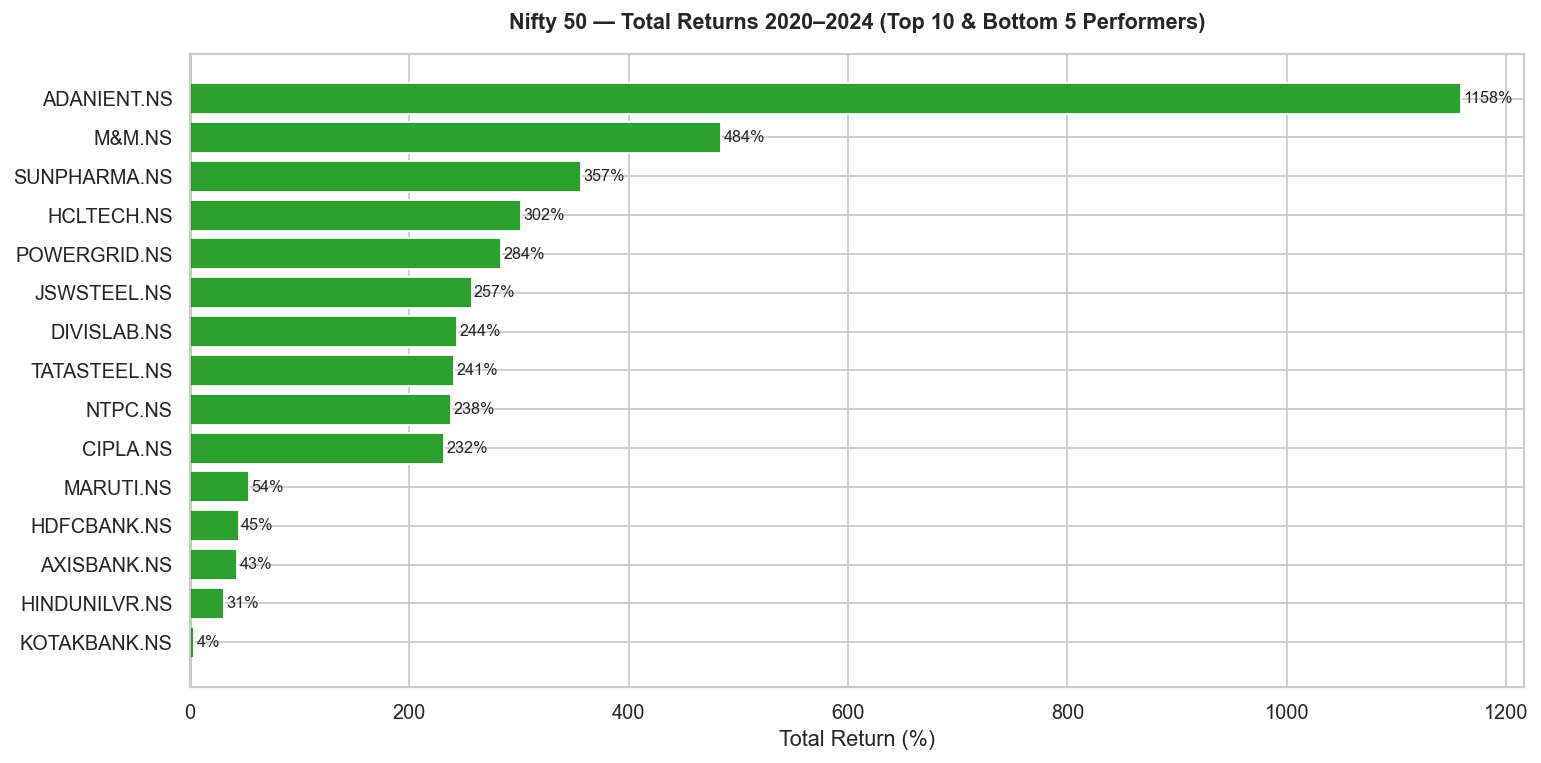

Saved.


In [8]:
# Chart 1: Total Returns Bar Chart — Top & Bottom performers
top10    = returns_df.head(10)
bottom5  = returns_df.tail(5)
plot_df  = pd.concat([top10, bottom5])

colors = ['#2ca02c' if r > 0 else '#d62728' for r in plot_df['total_return_pct']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(plot_df['ticker'], plot_df['total_return_pct'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, plot_df['total_return_pct']):
    ax.text(bar.get_width() + (2 if val >= 0 else -2), bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Nifty 50 — Total Returns 2020–2024 (Top 10 & Bottom 5 Performers)')
ax.set_xlabel('Total Return (%)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../assets/01_total_returns.png', bbox_inches='tight')
plt.show()
print('Saved.')

## 3. COVID Recovery Analysis

In [9]:
# COVID crash: market bottomed around March 23, 2020
# Measure recovery: price on Dec 31 2020 vs price on March 23 2020
crash_date    = '2020-03-23'
recovery_date = '2020-12-31'

# Get nearest available dates
crash_idx    = raw.index.searchsorted(pd.Timestamp(crash_date))
recovery_idx = raw.index.searchsorted(pd.Timestamp(recovery_date))

crash_prices    = raw.iloc[crash_idx]
recovery_prices = raw.iloc[min(recovery_idx, len(raw)-1)]

recovery_return = ((recovery_prices / crash_prices) - 1) * 100
recovery_df = recovery_return.reset_index()
recovery_df.columns = ['ticker', 'recovery_pct']
recovery_df = recovery_df.merge(sector_map, on='ticker', how='left')

# Average recovery by sector
sector_recovery = recovery_df.groupby('sector')['recovery_pct'].mean().sort_values(ascending=False).round(1)
print('Average sector recovery from COVID crash (Mar 2020 → Dec 2020):')
print(sector_recovery)

Average sector recovery from COVID crash (Mar 2020 → Dec 2020):
sector
Conglomerate    191.0
Metals          163.2
IT              116.6
Pharma           99.5
Auto             98.0
Banking          81.7
Energy           61.7
FMCG             38.9
Name: recovery_pct, dtype: float64


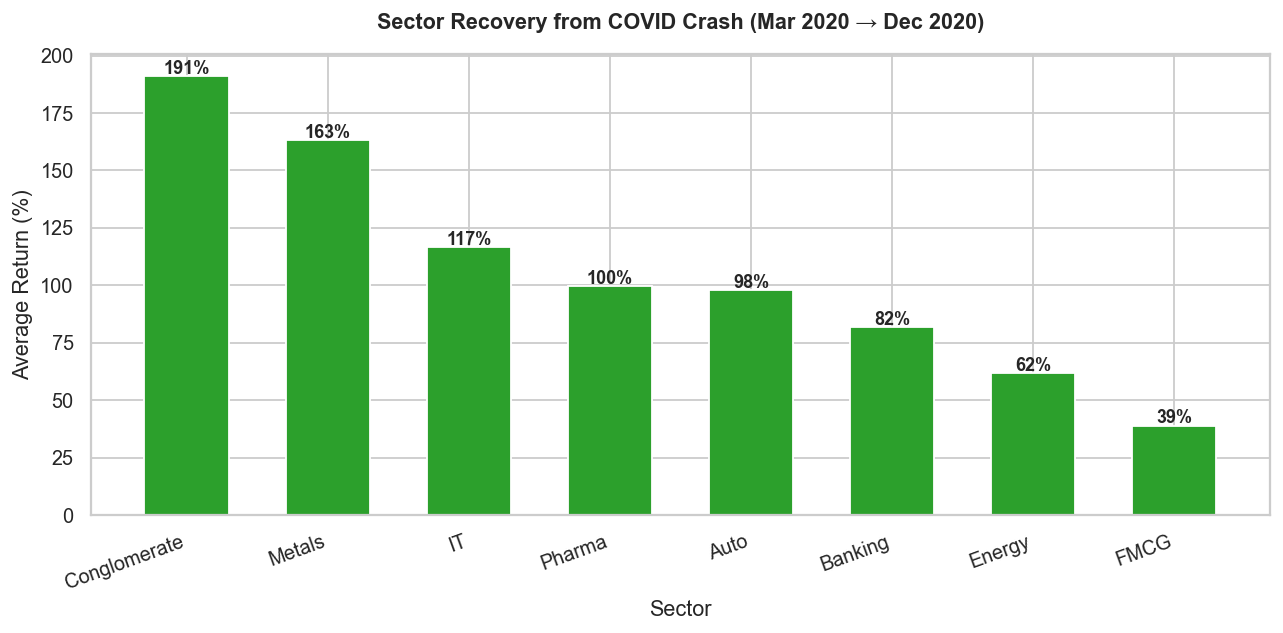

In [10]:
# Chart 2: Sector Recovery Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in sector_recovery.values]
bars = ax.bar(sector_recovery.index, sector_recovery.values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, sector_recovery.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Sector Recovery from COVID Crash (Mar 2020 → Dec 2020)')
ax.set_xlabel('Sector'); ax.set_ylabel('Average Return (%)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../assets/02_covid_recovery.png', bbox_inches='tight')
plt.show()

## 4. Volatility & Risk-Return Analysis

In [11]:
# Annualised volatility (std of daily returns * sqrt(252 trading days))
volatility = daily_returns.std() * np.sqrt(252) * 100
annualised_return = ((raw.iloc[-1] / raw.iloc[0]) ** (1/5) - 1) * 100  # 5-year CAGR

risk_return = pd.DataFrame({
    'ticker': volatility.index,
    'volatility_pct': volatility.values.round(2),
    'annual_return_pct': annualised_return.values.round(2)
})
risk_return = risk_return.merge(sector_map, on='ticker', how='left')

print('Risk-Return summary (annualised):')
print(risk_return.sort_values('annual_return_pct', ascending=False).head(10).to_string(index=False))

Risk-Return summary (annualised):
      ticker  volatility_pct  annual_return_pct       sector
 ADANIENT.NS           54.17              65.95 Conglomerate
      M&M.NS           34.11              42.35         Auto
SUNPHARMA.NS           25.59              35.49       Pharma
  HCLTECH.NS           27.74              32.06           IT
POWERGRID.NS           28.77              30.87       Energy
 JSWSTEEL.NS           35.80              28.98       Metals
 DIVISLAB.NS           29.37              28.00       Pharma
TATASTEEL.NS           37.62              27.79       Metals
     NTPC.NS           29.46              27.60       Energy
    CIPLA.NS           27.77              27.11       Pharma


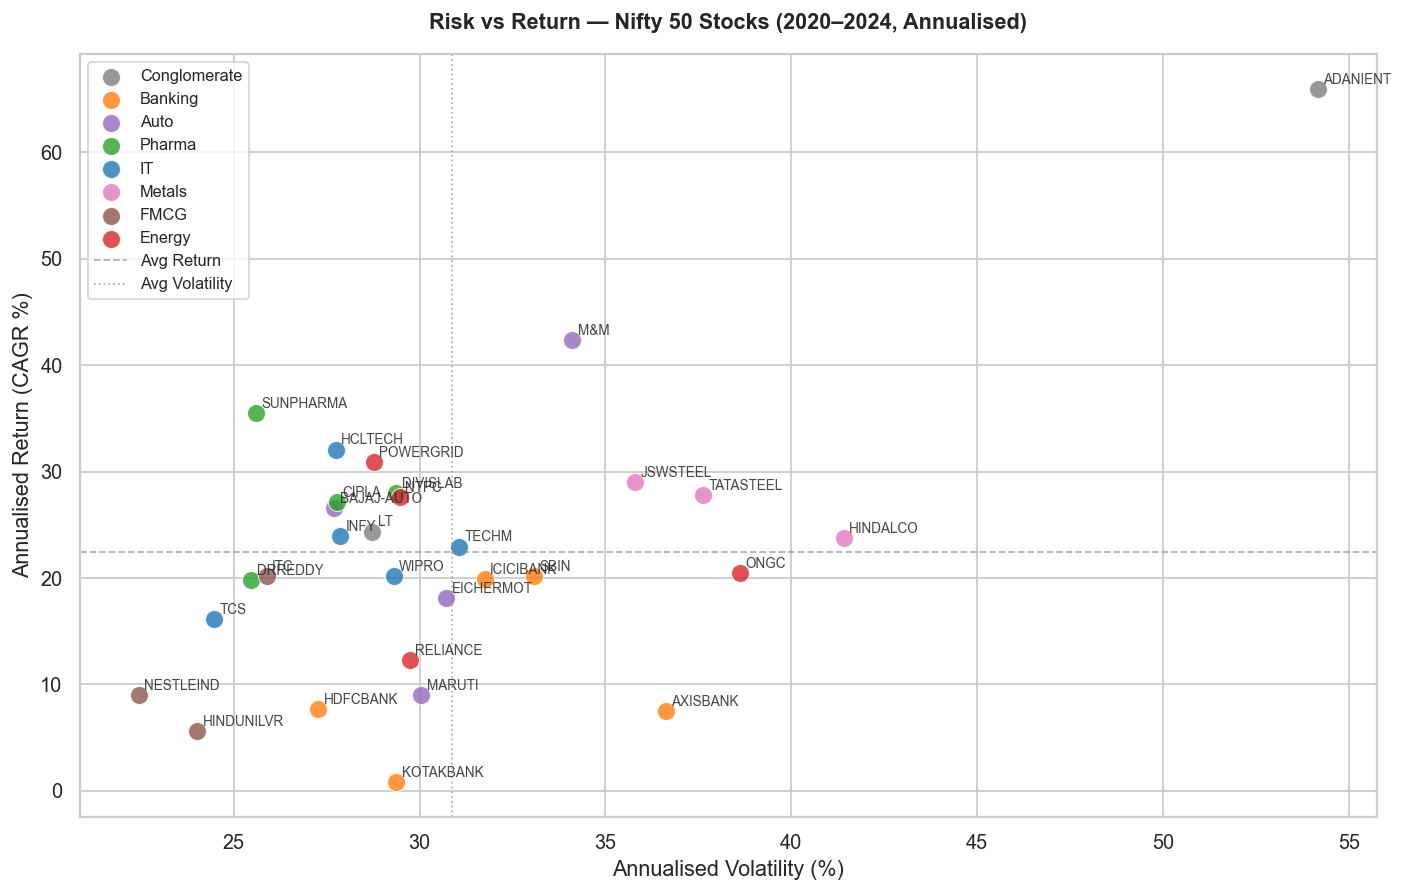

In [12]:
# Chart 3: Risk vs Return Scatter
sector_colors = {
    'IT': '#1f77b4', 'Banking': '#ff7f0e', 'Pharma': '#2ca02c',
    'Energy': '#d62728', 'Auto': '#9467bd', 'FMCG': '#8c564b',
    'Metals': '#e377c2', 'Conglomerate': '#7f7f7f'
}

fig, ax = plt.subplots(figsize=(11, 7))
for sector in risk_return['sector'].dropna().unique():
    subset = risk_return[risk_return['sector'] == sector]
    ax.scatter(subset['volatility_pct'], subset['annual_return_pct'],
               label=sector, color=sector_colors.get(sector, 'gray'),
               s=100, alpha=0.8, edgecolors='white', linewidth=0.6)

for _, row in risk_return.iterrows():
    label = row['ticker'].replace('.NS', '')
    ax.annotate(label, (row['volatility_pct'], row['annual_return_pct']),
                fontsize=7.5, xytext=(3, 3), textcoords='offset points', alpha=0.85)

ax.axhline(risk_return['annual_return_pct'].mean(), color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Avg Return')
ax.axvline(risk_return['volatility_pct'].mean(), color='gray', linestyle=':', linewidth=1, alpha=0.6, label='Avg Volatility')
ax.set_title('Risk vs Return — Nifty 50 Stocks (2020–2024, Annualised)')
ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Return (CAGR %)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.savefig('../assets/03_risk_return.png', bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

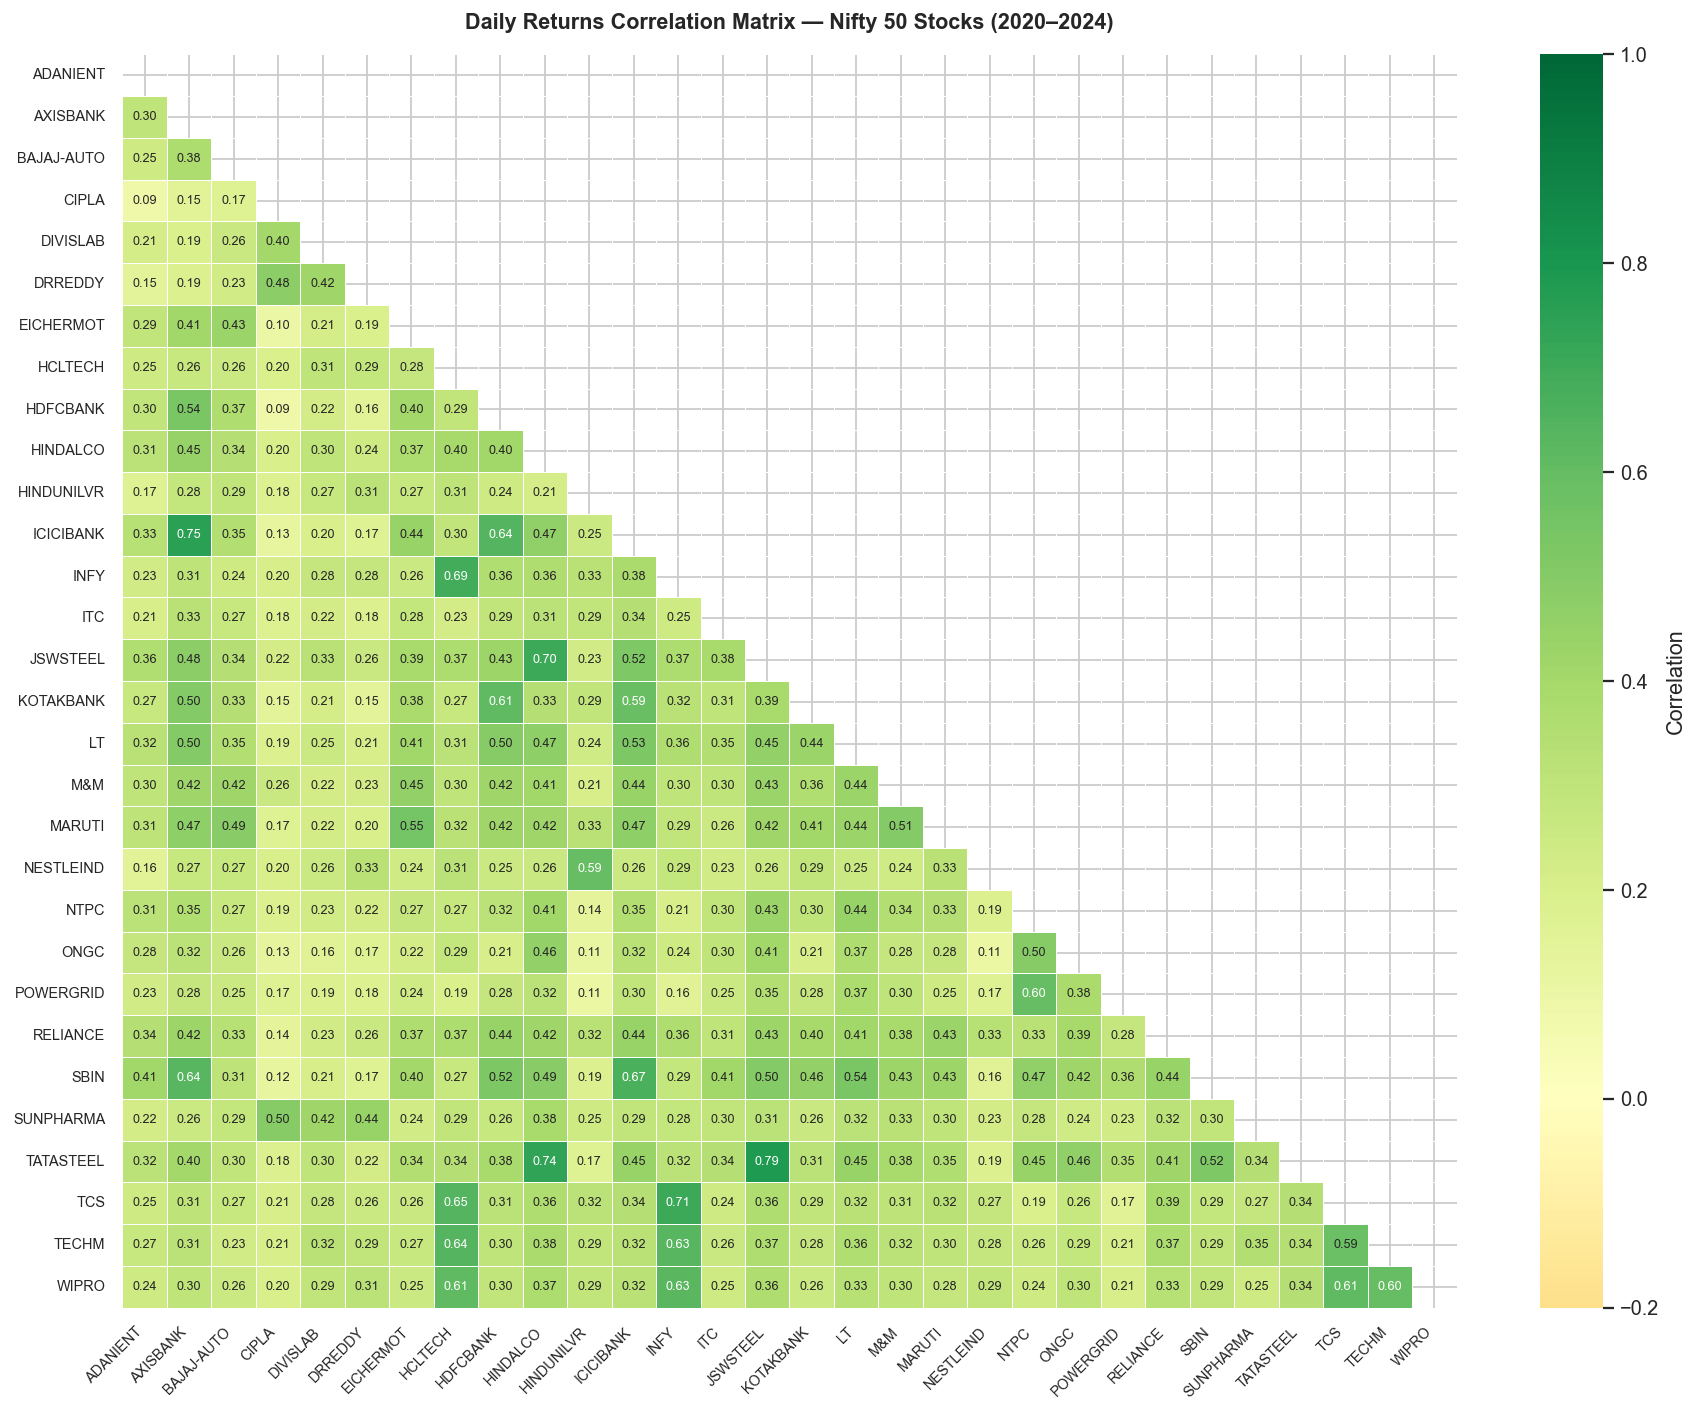


Highly correlated pairs (>0.8):


In [13]:
# Chart 4: Correlation Heatmap
# Rename columns to remove .NS suffix for readability
daily_returns_clean = daily_returns.copy()
daily_returns_clean.columns = [c.replace('.NS', '') for c in daily_returns_clean.columns]

corr_matrix = daily_returns_clean.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # show lower triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.2, vmax=1, linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Daily Returns Correlation Matrix — Nifty 50 Stocks (2020–2024)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('../assets/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('\nHighly correlated pairs (>0.8):')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i,j] > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i,j],3)))
for pair in sorted(high_corr, key=lambda x: -x[2]):
    print(f'  {pair[0]} ↔ {pair[1]}: {pair[2]}')

## 6. Rolling Returns — Top 5 Performers

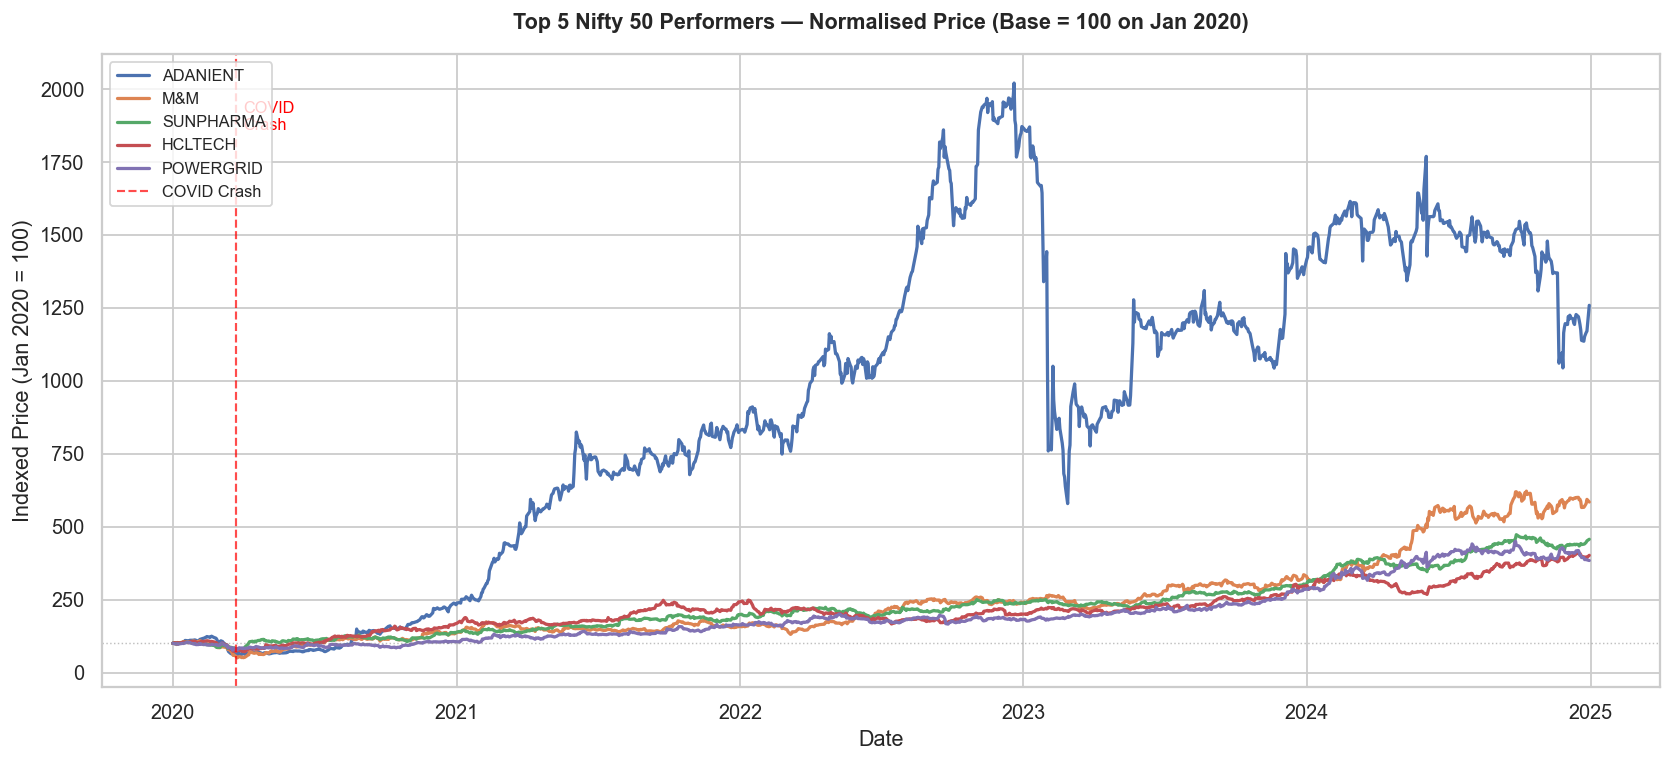

In [14]:
# Chart 5: Normalised price performance (base 100) for top 5 stocks
top5_tickers = returns_df.head(5)['ticker'].tolist()
top5_prices  = raw[top5_tickers]

# Normalise to 100 at start
normalised = (top5_prices / top5_prices.iloc[0]) * 100
normalised.columns = [c.replace('.NS', '') for c in normalised.columns]

fig, ax = plt.subplots(figsize=(13, 6))
for col in normalised.columns:
    ax.plot(normalised.index, normalised[col], linewidth=1.8, label=col)

# Annotate COVID crash
ax.axvline(pd.Timestamp('2020-03-23'), color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='COVID Crash')
ax.text(pd.Timestamp('2020-04-01'), normalised.values.max() * 0.92, 'COVID\nCrash', fontsize=9, color='red')

ax.axhline(100, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_title('Top 5 Nifty 50 Performers — Normalised Price (Base = 100 on Jan 2020)')
ax.set_xlabel('Date'); ax.set_ylabel('Indexed Price (Jan 2020 = 100)')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
plt.tight_layout()
plt.savefig('../assets/05_top5_performance.png', bbox_inches='tight')
plt.show()

## 7. The Maximum Drawdown Curve

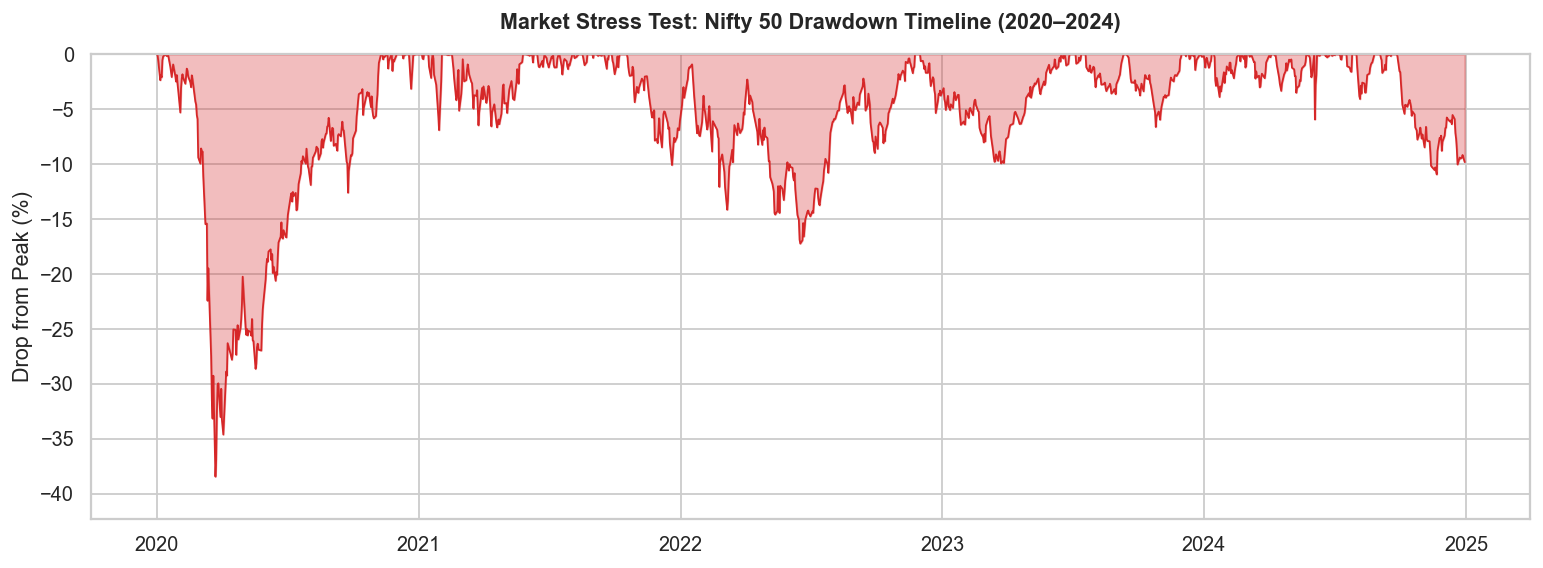

Max Market Pain Point: -38.44% drop during the timeline.


In [ ]:
#chart 6: Market Drawdown Timeline (Nifty 50)
index_ticker = '^NSEI'

if index_ticker in raw.columns:
    index_prices = raw[index_ticker]
    rolling_peak = index_prices.cummax()
    drawdown = (index_prices - rolling_peak) / rolling_peak * 100

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.fill_between(drawdown.index, drawdown, 0, color='#d62728', alpha=0.3, label='Nifty 50 Drawdown')
    ax.plot(drawdown.index, drawdown, color='#d62728', linewidth=1)
    ax.set_title('Market Stress Test: Nifty 50 Drawdown Timeline (2020–2024)')
    ax.set_ylabel('Drop from Peak (%)')
    ax.set_ylim(drawdown.min() * 1.1, 0)
    plt.tight_layout()
    plt.savefig('../assets/06_market_drawdown.png', bbox_inches='tight')
    plt.show()
    print(f"Max Market Pain Point: {drawdown.min():.2f}% drop during the timeline.")

## 8. The Beta vs. Alpha Distribution

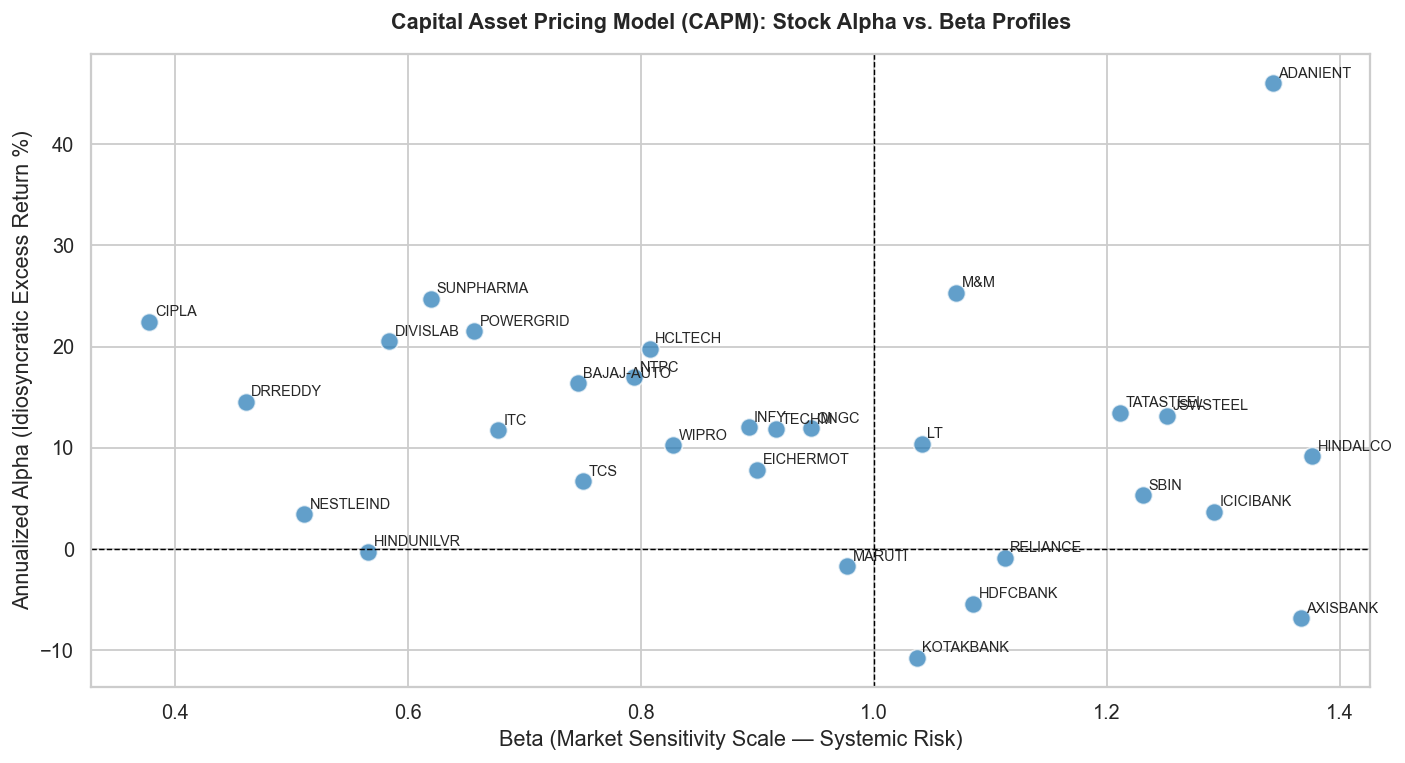

📊 Successfully generated CAPM matrix for 30 stocks.


In [ ]:
#chart 7: CAPM Alpha vs Beta Frontier
from scipy.stats import linregress

alphas, betas = [], []
index_ticker = '^NSEI'

# Step 1: Calculate the true market benchmark returns directly from the source 'raw' table
if index_ticker in raw.columns:
    market_returns = raw[index_ticker].pct_change().dropna()
    
    # Step 2: Loop through the corporate stocks in your risk tracking summary table
    for ticker in risk_return['ticker']:
        if ticker in raw.columns and ticker != index_ticker:
            # Calculate the stock's daily returns directly from the clean raw column
            stock_returns = raw[ticker].pct_change().dropna()
            
            # Step 3: Align the dates perfectly in case of any micro mismatch gaps
            aligned_data = pd.concat([market_returns, stock_returns], axis=1).dropna()
            aligned_data.columns = ['market', 'stock']
            
            # Execute Ordinary Least Squares (OLS) linear regression
            slope, intercept, _, _, _ = linregress(aligned_data['market'], aligned_data['stock'])
            
            betas.append(slope)
            alphas.append(intercept * 252 * 100) # Annualize the intercept to get Alpha %

    # Build the final presentation matrix
    metrics_df = pd.DataFrame({
        'ticker': [t.replace('.NS', '') for t in risk_return['ticker'] if t != index_ticker], 
        'Beta': betas, 
        'Alpha': alphas
    })

    # Render the advanced CAPM scatter visualization
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.scatter(metrics_df['Beta'], metrics_df['Alpha'], color='#1f77b4', s=100, alpha=0.7, edgecolors='white')

    for _, row in metrics_df.iterrows():
        ax.annotate(row['ticker'], (row['Beta'], row['Alpha']), fontsize=8, xytext=(3,3), textcoords='offset points')

    # Draw standard baseline thresholds
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    
    ax.set_title('Capital Asset Pricing Model (CAPM): Stock Alpha vs. Beta Profiles')
    ax.set_xlabel('Beta (Market Sensitivity Scale — Systemic Risk)')
    ax.set_ylabel('Annualized Alpha (Idiosyncratic Excess Return %)')
    
    plt.tight_layout()
    plt.savefig('../assets/07_alpha_beta_frontier.png', bbox_inches='tight')
    plt.show()
    print(f"📊 Successfully generated CAPM matrix for {len(metrics_df)} stocks.")
else:
    print("⚠️ Critical Error: '^NSEI' was not found in the raw DataFrame columns. Please re-run Cell 3.")

## 9. Sector Volatility Clustering

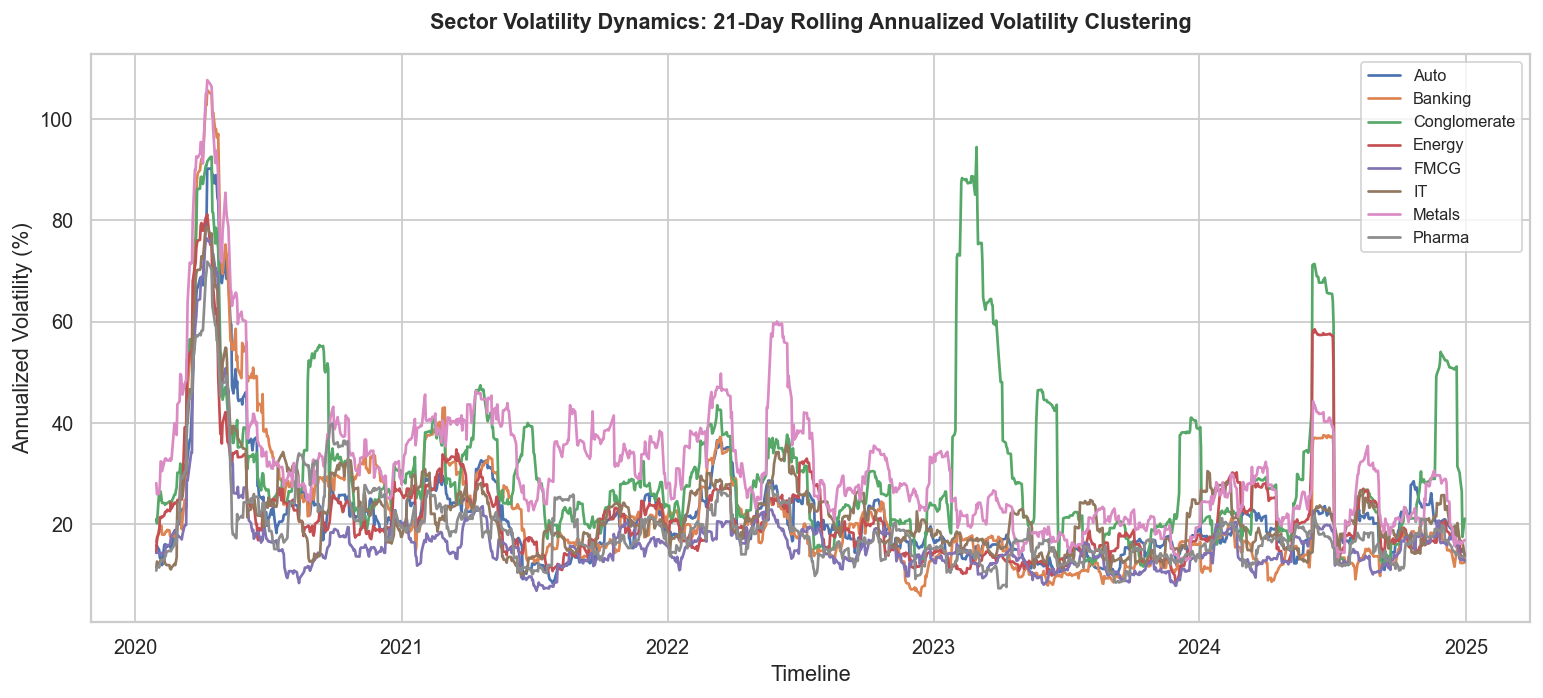

📊 Successfully generated sector volatility clustering timelines.


In [ ]:
#chart 8: Sector Volatility Clustering Timeline
raw_returns = raw.pct_change().dropna()

# Step 2: Drop the market index from the matrix so it doesn't skew corporate sector averages
if '^NSEI' in raw_returns.columns:
    corporate_returns = raw_returns.drop('^NSEI', axis=1)
else:
    corporate_returns = raw_returns.copy()

# Step 3: Melt the wide matrix to a long format to map sectors cleanly
long_returns = corporate_returns.melt(var_name='ticker', value_name='daily_return', ignore_index=False)
long_returns = long_returns.reset_index().merge(sector_map, on='ticker', how='left')

# Step 4: Group by Date and Sector to get the average daily return per industry cluster
sector_daily_avg = long_returns.groupby(['Date', 'sector'])['daily_return'].mean().unstack()

# Step 5: Compute the 21-day (one trading month) rolling annualized volatility
# Volatility scales with the square root of trading days (252)
rolling_vol = sector_daily_avg.rolling(window=21).std() * np.sqrt(252) * 100

# Step 6: Render the dynamic Volatility Clustering plot
fig, ax = plt.subplots(figsize=(12, 5.5))
for col in rolling_vol.columns:
    ax.plot(rolling_vol.index, rolling_vol[col], label=col, linewidth=1.5)

ax.set_title('Sector Volatility Dynamics: 21-Day Rolling Annualized Volatility Clustering')
ax.set_xlabel('Timeline')
ax.set_ylabel('Annualized Volatility (%)')
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)

plt.tight_layout()
plt.savefig('../assets/08_volatility_clustering.png', bbox_inches='tight')
plt.show()
print("📊 Successfully generated sector volatility clustering timelines.")

## 10. Key Findings Summary

In [15]:
best_stock = returns_df.iloc[0]
worst_stock = returns_df.iloc[-1]
best_sector = sector_recovery.index[0]
most_volatile = risk_return.loc[risk_return['volatility_pct'].idxmax()]
avg_market_return = returns_df['total_return_pct'].mean()

print('=' * 60)
print('KEY FINDINGS — NIFTY 50 ANALYSIS (2020–2024)')
print('=' * 60)
print(f'Best performer:      {best_stock["ticker"].replace(".NS","")} (+{best_stock["total_return_pct"]:.0f}%)')
print(f'Worst performer:     {worst_stock["ticker"].replace(".NS","")} ({worst_stock["total_return_pct"]:.0f}%)')
print(f'Avg market return:   {avg_market_return:.0f}% over 5 years')
print(f'Fastest COVID recovery sector: {best_sector} ({sector_recovery.iloc[0]:.0f}% in 9 months)')
print(f'Most volatile stock: {most_volatile["ticker"].replace(".NS","")} ({most_volatile["volatility_pct"]:.1f}% annualised vol)')
print('\nAll charts saved to assets/')

KEY FINDINGS — NIFTY 50 ANALYSIS (2020–2024)
Best performer:      ADANIENT (+1158%)
Worst performer:     KOTAKBANK (4%)
Avg market return:   208% over 5 years
Fastest COVID recovery sector: Conglomerate (191% in 9 months)
Most volatile stock: ADANIENT (54.2% annualised vol)

All charts saved to assets/
